In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

#1.生成模拟数据：200套公寓
np.random.seed(42)
#假设面积：15-50平方米
area = np.random.uniform(15, 50, 200)
#假设距离地铁站的时间在1-15分钟之间
distance = np.random.uniform(1, 15, 200)
#模拟真实租金，规律为：基础租金 + 面积加成 - 距离惩罚 + 随机波动
rent = 3.0 + 0.2 * area - 0.1 * distance + np.random.normal(0, 0.5, 200)
#将数据组合成DataFrame
df = pd.DataFrame({'area_sqm': area,
                     'distance_min': distance,
                     'rent_10k_JPY': rent})

print("前5行数据：")
print(df.head()) 

前5行数据：
    area_sqm  distance_min  rent_10k_JPY
0  28.108904      9.988443      8.275676
1  48.275001      2.177960     12.447706
2  40.619788      3.262802     11.138654
3  35.953047     13.579759      8.677500
4  20.460652      9.490007      6.305213


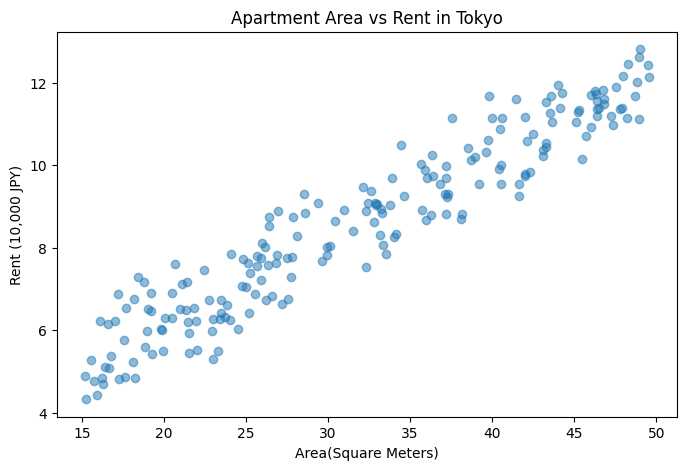

In [11]:
#matplotlib画出散点图
plt.figure(figsize=(8, 5))
plt.scatter(df['area_sqm'], df['rent_10k_JPY'], alpha=0.5)
plt.title('Apartment Area vs Rent in Tokyo')
plt.xlabel('Area(Square Meters)')
plt.ylabel('Rent (10,000 JPY)')
plt.show()  

开始在gpu上炼丹


2026-03-10 20:35:36.560233: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-10 20:35:36.582529: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


训练完成！


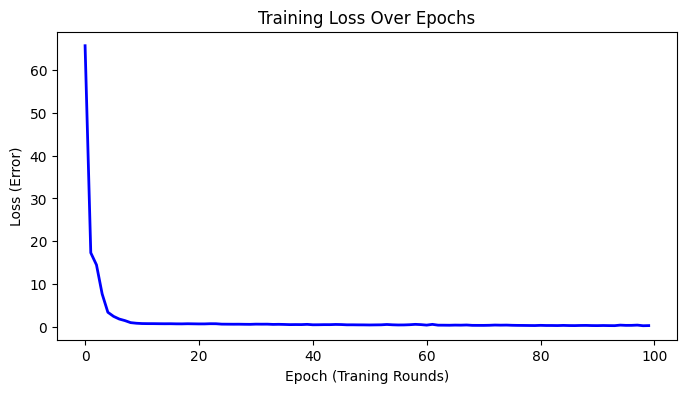

In [16]:
#提取特征（x：面积和距离）和标签（y：租金）
X = df[['area_sqm','distance_min']].values
Y = df['rent_10k_JPY'].values

#搭建模型：一个包含隐藏层的神经网络
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1)  # 输出层，预测租金
])
#编译模型，告诉他怎么评估自己猜的准不准
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05), loss='mse')
print("开始在gpu上炼丹")
#训练模型 让模型把200条数据反复看100遍
history = model.fit(X, Y, epochs=100, verbose=0)
print("训练完成！")
#再次画图，看看模型学得怎么样了
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],c='blue',linewidth=2)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch (Traning Rounds)')
plt.ylabel('Loss (Error)')
plt.show()

In [17]:
#假设看中了一套房子，面积25平方米，距离地铁5分钟
#打包数据
new_apartment = np.array([[25.0, 5.0]])
#让模型预测租金
predicted_rent = model.predict(new_apartment)
print(f"预测的租金（10,000 JPY）：{predicted_rent[0][0]:.2f}")

1/1 [==============================] - 0s 383ms/step
预测的租金（10,000 JPY）：7.03
